# Apple CDP Climate Disclosure — Data Visualization & Review

Source file: `Apple_Responses.xlsx` (CDP public response extract, 2021–2025).

This notebook builds the report figures and tables for Apple's climate disclosures. It also flags **data-quality ("fishy")
observations** — where Apple's reported numbers look static or internally inconsistent across years — so you can review
before writing the final report.

> **Note on the `year` axis:** the CDP questionnaire year maps to the *fiscal year just reported*. e.g. the 2021 response
carries FY2020 data, the 2025 response carries FY2024 data. We chart the questionnaire year as labelled in the workbook.

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

DF = pd.read_excel("Apple_Responses.xlsx")
YEARS = [2021, 2022, 2023, 2024, 2025]

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})
APPLE = {  # Apple-ish muted palette
    "navy":   "#1d1d1f",
    "gray":   "#86868b",
    "blue":   "#0071e3",
    "green":  "#34c759",
    "orange": "#ff9500",
    "red":    "#ff3b30",
}

def _num(s):
    """Extract the first float from a response value or text blob."""
    if isinstance(s, float) and np.isnan(s):
        return np.nan
    t = str(s).replace(',', '')
    m = re.search(r'-?\d+\.?\d*', t)
    return float(m.group(0)) if m else np.nan

## Extract the key quantitative series

All values are pulled straight from `Apple_Responses.xlsx`. Emission units are **metric tons CO2e**; energy units are **MWh**.
The workbook contains two schemas (2021–23 old CDP layout, 2024–25 new layout), so each helper branches on the year.

In [4]:
def get_text(year, sid):
    rows = DF[(DF.year == year) & (DF.str.astype(str) == sid)]
    if rows.empty or pd.isna(rows.response.iloc[0]):
        return ""
    return str(rows.response.iloc[0])

def scope1():
    out = {}
    for y in YEARS:
        if y <= 2023:
            t = get_text(y, "6.1")
            nums = [float(x.replace(',', '')) for x in
                    re.findall(r"Gross global Scope 1 emissions \(metric tons CO2e\)\n([0-9,]+)", t)]
            out[y] = nums[0] if nums else np.nan
        else:
            out[y] = _num(get_text(y, "7.6.1"))
    return out

def scope2():
    loc, mkt = {}, {}
    for y in YEARS:
        if y <= 2023:
            t = get_text(y, "6.3")
            m = re.search(r"Scope 2, location-based\n([0-9,]+)\nScope 2, market-based \(if applicable\)\n([0-9,]*)", t)
            loc[y] = float(m.group(1).replace(',', '')) if m else np.nan
            mkt[y] = float(m.group(2).replace(',', '')) if m and m.group(2) else np.nan
        else:
            loc[y] = _num(get_text(y, "7.7.1"))
            m = _num(get_text(y, "7.7.2"))
            mkt[y] = m if not np.isnan(m) else np.nan
    return loc, mkt

def scope3_cat1():
    out = {}
    for y in YEARS:
        if y <= 2023:
            t = get_text(y, "6.5")
            i = t.find("Purchased goods and services")
            seg = t[i:i + 500]
            nums = [float(x.replace(',', '')) for x in
                    re.findall(r"(?:Metric tonnes CO2e|Emissions in reporting year \(metric tons CO2e\))\n([0-9,]+)", seg)]
            out[y] = nums[0] if nums else np.nan
        else:
            r = DF[(DF.year == y) & (DF.str.astype(str) == "7.8.2") &
                   (DF.row_label == "Purchased goods and services")]
            out[y] = _num(r.response.iloc[0]) if not r.empty else np.nan
    return out

def revenue():
    out = {}
    for y in YEARS:
        if y <= 2023:
            t = get_text(y, "6.10")
            m = re.search(r"Metric denominator: Unit total\n([0-9]+)", t)
            out[y] = float(m.group(1)) if m else np.nan
        else:
            out[y] = _num(get_text(y, "1.4.1"))
    return out

def energy():
    pe, sgr = {}, {}
    for y in YEARS:
        if y <= 2023:
            t = get_text(y, "8.2a")
            p = re.search(r"Consumption of purchased or acquired electricity\n(?:<Not Applicable>|[0-9,]+)\n([0-9,]+)\n([0-9,]+)", t)
            pe[y] = float(p.group(2).replace(',', '')) if p else np.nan
            s = re.search(r"self-generated non-fuel renewable energy\n(?:<Not Applicable>|[0-9,]+)\n([0-9,]+)\n(?:<Not Applicable>|[0-9,]+)\n([0-9,]+)", t)
            sgr[y] = float(s.group(2).replace(',', '')) if s else np.nan
        else:
            for key, out in [("Consumption of purchased or acquired electricity", pe),
                             ("Consumption of self-generated non-fuel renewable energy", sgr)]:
                r = DF[(DF.year == y) & (DF.str.astype(str) == "7.30.1.4") & (DF.row_label == key)]
                out[y] = _num(r.response.iloc[0]) if not r.empty else np.nan
    return pe, sgr

S1 = scope1()
S2_loc, S2_mkt = scope2()
S3_c1 = scope3_cat1()
REV = revenue()
PE, SGR = energy()

# Intensity numerator = Scope 1 + market-based Scope 2 (the metric Apple reports)
INT_N = {y: (S1[y] + (S2_mkt[y] if not np.isnan(S2_mkt[y]) else 0)) for y in YEARS}
INT = {y: INT_N[y] / REV[y] for y in YEARS}

print("Scope 1 (tCO2e):    ", {y: int(v) for y, v in S1.items()})
print("Scope 2 loc (tCO2e):", {y: int(v) for y, v in S2_loc.items()})
print("Scope 2 mkt (tCO2e):", {y: (int(v) if not np.isnan(v) else None) for y, v in S2_mkt.items()})
print("Scope3 Cat1 (tCO2e):", {y: int(v) for y, v in S3_c1.items()})
print("Revenue (USD):       ", {y: int(v) for y, v in REV.items()})
print("Purchased elec (MWh):", {y: int(v) for y, v in PE.items()})
print("Self-gen renew (MWh):", {y: int(v) for y, v in SGR.items()})
print("Intensity (t CO2e/$):", {y: round(v, 10) for y, v in INT.items()})

Scope 1 (tCO2e):     {2021: 47430, 2022: 55200, 2023: 55200, 2024: 55200, 2025: 55200}
Scope 2 loc (tCO2e): {2021: 890200, 2022: 1003246, 2023: 1065405, 2024: 1206700, 2025: 1224500}
Scope 2 mkt (tCO2e): {2021: None, 2022: 2780, 2023: 3000, 2024: 3400, 2025: 3300}
Scope3 Cat1 (tCO2e): {2021: 16100000, 2022: 16200000, 2023: 13400000, 2024: 9400000, 2025: 8200000}
Revenue (USD):        {2021: 274515000000, 2022: 365817000000, 2023: 394328000000, 2024: 383285000000, 2025: 391035000000}
Purchased elec (MWh): {2021: 993190, 2022: 1091272, 2023: 3112157, 2024: 3489033, 2025: 3349714}
Self-gen renew (MWh): {2021: 1501510, 2022: 1690223, 2023: 50767, 2024: 371781, 2025: 424591}
Intensity (t CO2e/$): {2021: 1.728e-07, 2022: 1.585e-07, 2023: 1.476e-07, 2024: 1.529e-07, 2025: 1.496e-07}


## Figure 1 — Trend of Apple's Scope 1 Emissions (2021–2025)

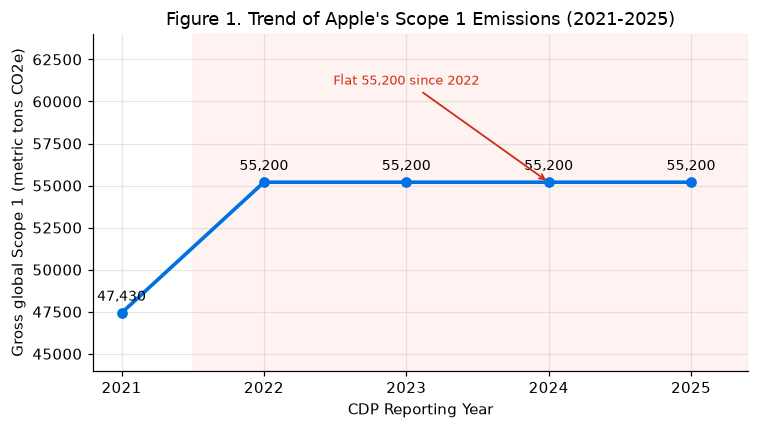

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(YEARS)
ys = [S1[y] for y in xs]
ax.plot(xs, ys, marker='o', lw=2.4, color=APPLE['blue'], label='Scope 1')
for x, v in zip(xs, ys):
    ax.annotate(f"{int(v):,}", (x, v), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
ax.axvspan(2021.5, 2025.4, color=APPLE['red'], alpha=0.06)
ax.set_title("Figure 1. Trend of Apple's Scope 1 Emissions (2021-2025)")
ax.set_xlabel("CDP Reporting Year")
ax.set_ylabel("Gross global Scope 1 (metric tons CO2e)")
ax.set_xticks(xs)
ax.set_xlim(2020.8, 2025.4)
ax.set_ylim(44000, 64000)
ax.grid(True, axis='y')
ax.annotate("Flat 55,200 since 2022",
            xy=(2024, 55200), xytext=(2023.0, 61000), fontsize=8.5, color='#cc2f15', ha='center',
            arrowprops=dict(arrowstyle='->', color='#cc2f15', lw=1.2))
fig.tight_layout(); plt.show()

## Figure 2 — Location-Based vs Market-Based Scope 2 Emissions

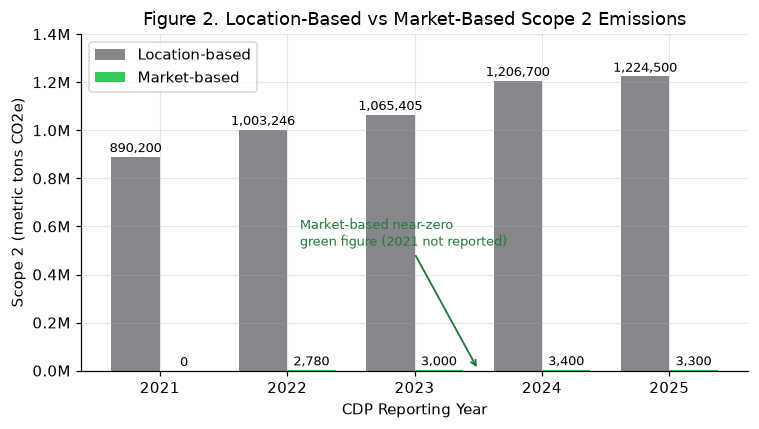

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(YEARS)
mloc = [S2_loc[y] for y in xs]
mmkt = [0 if np.isnan(S2_mkt[y]) else S2_mkt[y] for y in xs]
w = 0.38
ax.bar([x - w/2 for x in xs], mloc, w, color=APPLE['gray'], label='Location-based')
ax.bar([x + w/2 for x in xs], mmkt, w, color=APPLE['green'], label='Market-based')
for x, v in zip(xs, mloc):
    ax.annotate(f"{int(v):,}", (x - w/2, v), textcoords="offset points", xytext=(0, 3), ha='center', fontsize=8.5)
for x, v in zip(xs, mmkt):
    ax.annotate(f"{int(v):,}", (x + w/2, v), textcoords="offset points", xytext=(0, 3), ha='center', fontsize=8.5)
ax.set_title("Figure 2. Location-Based vs Market-Based Scope 2 Emissions")
ax.set_xlabel("CDP Reporting Year"); ax.set_ylabel("Scope 2 (metric tons CO2e)")
ax.set_xticks(xs)
ax.legend(loc='upper left')
ax.set_ylim(0, 1.4e6)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax.annotate("Market-based near-zero\ngreen figure (2021 not reported)",
            xy=(2023.5, 3000), xytext=(2022.1, 5.2e5), fontsize=8.5, color='#1f7a38',
            arrowprops=dict(arrowstyle='->', color='#1f7a38', lw=1.2))
fig.tight_layout(); plt.show()

## Figure 3 — Trend of Scope 3 Purchased Goods & Services Emissions

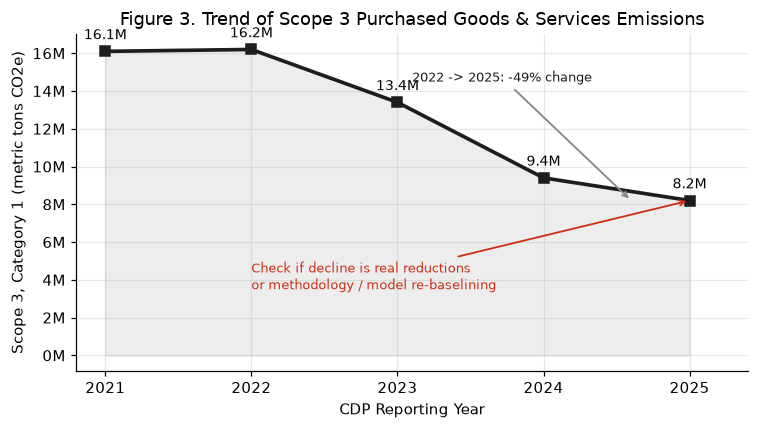

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(YEARS)
ys = [S3_c1[y] for y in xs]
ax.plot(xs, ys, marker='s', lw=2.4, color=APPLE['navy'], label='Scope 3 Category 1')
ax.fill_between(xs, ys, color=APPLE['navy'], alpha=0.08)
for x, v in zip(xs, ys):
    ax.annotate(f"{v/1e6:.1f}M", (x, v), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
pct = (ys[4]-ys[1])/ys[1]*100
ax.annotate(f"2022 -> 2025: {pct:.0f}% change", xy=(2024.6, ys[4]),
            xytext=(2023.1, 14.5e6), fontsize=8.5, color='#1d1d1f',
            arrowprops=dict(arrowstyle='->', color='#86868b', lw=1.2))
ax.set_title("Figure 3. Trend of Scope 3 Purchased Goods & Services Emissions")
ax.set_xlabel("CDP Reporting Year"); ax.set_ylabel("Scope 3, Category 1 (metric tons CO2e)")
ax.set_xticks(xs); ax.set_xlim(2020.8, 2025.4)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.annotate("Check if decline is real reductions\nor methodology / model re-baselining",
            xy=(2025, 8.2e6), xytext=(2022.0, 3.5e6), fontsize=8.5, color='#cc2f15',
            arrowprops=dict(arrowstyle='->', color='#cc2f15', lw=1.2))
fig.tight_layout(); plt.show()

## Figure 4 — Operational Emissions Intensity (Scope 1 + Market-Based Scope 2 per Revenue)

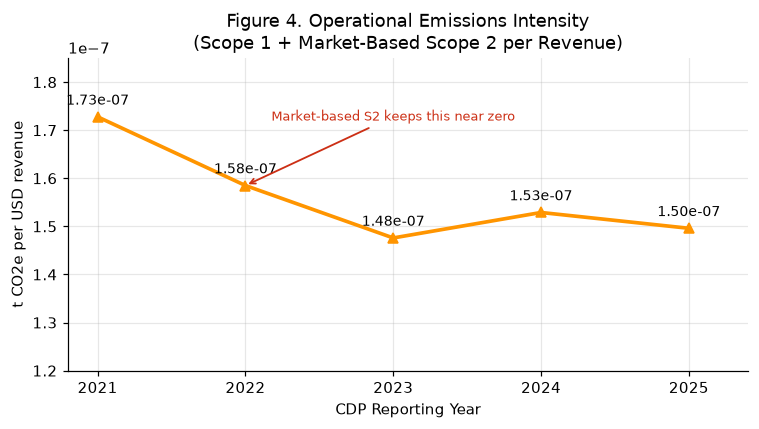

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(YEARS)
ys = [INT[y] for y in xs]
ax.plot(xs, ys, marker='^', lw=2.4, color=APPLE['orange'], label='Intensity')
for x, v in zip(xs, ys):
    ax.annotate(f"{v:.2e}", (x, v), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
ax.set_title("Figure 4. Operational Emissions Intensity\n(Scope 1 + Market-Based Scope 2 per Revenue)")
ax.set_xlabel("CDP Reporting Year"); ax.set_ylabel("t CO2e per USD revenue")
ax.set_xticks(xs); ax.set_xlim(2020.8, 2025.4); ax.set_ylim(1.2e-7, 1.85e-7)
ax.annotate("Market-based S2 keeps this near zero",
            xy=(2022, 1.585e-7), xytext=(2023.0, 1.72e-7), fontsize=8.5, color='#cc2f15', ha='center',
            arrowprops=dict(arrowstyle='->', color='#cc2f15', lw=1.2))
fig.tight_layout(); plt.show()

## Figure 5 — Purchased Electricity vs Self-Generated Renewable Electricity (2021–2025)

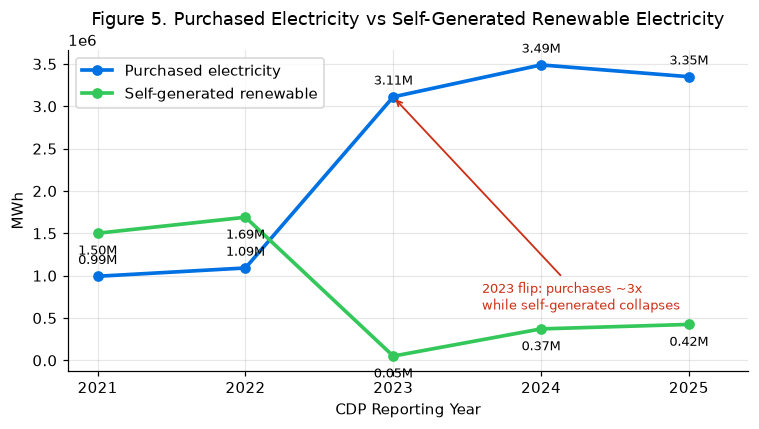

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(YEARS)
pe = [PE[y] for y in xs]
sg = [SGR[y] for y in xs]
ax.plot(xs, pe, marker='o', lw=2.4, color=APPLE['blue'], label='Purchased electricity')
ax.plot(xs, sg, marker='o', lw=2.4, color=APPLE['green'], label='Self-generated renewable')
for x, v in zip(xs, pe):
    ax.annotate(f"{v/1e6:.2f}M", (x, v), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8.5)
for x, v in zip(xs, sg):
    ax.annotate(f"{v/1e6:.2f}M", (x, v), textcoords="offset points", xytext=(0, -14), ha='center', fontsize=8.5)
ax.set_title("Figure 5. Purchased Electricity vs Self-Generated Renewable Electricity")
ax.set_xlabel("CDP Reporting Year"); ax.set_ylabel("MWh")
ax.set_xticks(xs); ax.set_xlim(2020.8, 2025.4)
ax.legend(loc='upper left')
ax.annotate("2023 flip: purchases ~3x\nwhile self-generated collapses",
            xy=(2023, 3.11e6), xytext=(2023.6, 0.6e6), fontsize=8.5, color='#cc2f15',
            arrowprops=dict(arrowstyle='->', color='#cc2f15', lw=1.2))
fig.tight_layout(); plt.show()

## Figure 6 — Overall Trend of Apple's Major Emission Categories (Scope 1, Scope 2, Scope 3)

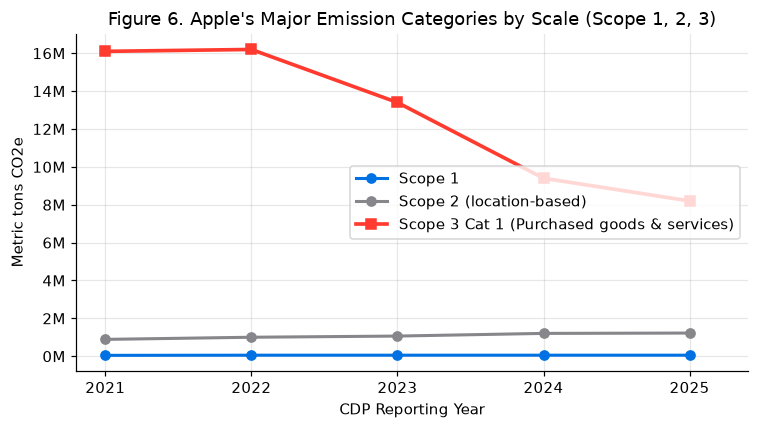

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = list(YEARS)
s1 = [S1[y] for y in xs]
s2 = [S2_loc[y] for y in xs]
s3 = [S3_c1[y] for y in xs]
ax.plot(xs, s1, marker='o', lw=2, color=APPLE['blue'], label='Scope 1')
ax.plot(xs, s2, marker='o', lw=2, color=APPLE['gray'], label='Scope 2 (location-based)')
ax.plot(xs, s3, marker='s', lw=2.4, color=APPLE['red'], label='Scope 3 Cat 1 (Purchased goods & services)')
ax.set_title("Figure 6. Apple's Major Emission Categories by Scale (Scope 1, 2, 3)")
ax.set_xlabel("CDP Reporting Year"); ax.set_ylabel("Metric tons CO2e")
ax.set_xticks(xs); ax.set_xlim(2020.8, 2025.4)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.legend(loc='center right')
fig.tight_layout(); plt.show()

## Table 1 — Summary of Key Quantitative Variables

In [11]:
def fmt(v):
    return "n/a" if (isinstance(v, float) and np.isnan(v)) else f"{v:,.0f}"

t1 = pd.DataFrame({
    "Variable": [
        "Scope 1 emissions (tCO2e)",
        "Scope 2, location-based (tCO2e)",
        "Scope 2, market-based (tCO2e)",
        "Scope 3 Cat 1 - Purchased goods & services (tCO2e)",
        "Revenue (USD)",
        "Emissions intensity (t CO2e/USD)",
        "Purchased electricity (MWh)",
        "Self-generated renewable (MWh)",
    ],
    **{str(y): [fmt(v) for v in (S1[y], S2_loc[y], S2_mkt[y], S3_c1[y], REV[y], INT[y], PE[y], SGR[y])] for y in YEARS},
})

notes = pd.Series([
    "FISHY: identical 55,200 for 2022-2025 (4 straight years).",
    "Rising steadily with data-centre growth.",
    "Near-zero & renewable-driven; 2021 not reported.",
    "Check whether decline is real or methodology re-baselining.",
    "Fiscal-year revenue (reported prior FY).",
    "Uses market-based Scope 2; excludes grid emissions.",
    "FISHY: ~3x jump 2022->2023.",
    "Collapses 2022->2023 alongside purchased spike.",
])
t1["Notes / Data flag"] = notes
t1.style.hide(axis='index').set_properties(**{'text-align': 'left'})

Variable,2021,2022,2023,2024,2025,Notes / Data flag
Scope 1 emissions (tCO2e),"47,430","55,200","55,200","55,200","55,200","FISHY: identical 55,200 for 2022-2025 (4 straight years)."
"Scope 2, location-based (tCO2e)","890,200","1,003,246","1,065,405","1,206,700","1,224,500",Rising steadily with data-centre growth.
"Scope 2, market-based (tCO2e)",n/a,"2,780","3,000","3,400","3,300",Near-zero & renewable-driven; 2021 not reported.
Scope 3 Cat 1 - Purchased goods & services (tCO2e),"16,100,000","16,200,000","13,400,000","9,400,000","8,200,000",Check whether decline is real or methodology re-baselining.
Revenue (USD),"274,515,000,000","365,817,000,000","394,328,000,000","383,285,000,000","391,035,000,000",Fiscal-year revenue (reported prior FY).
Emissions intensity (t CO2e/USD),0,0,0,0,0,Uses market-based Scope 2; excludes grid emissions.
Purchased electricity (MWh),"993,190","1,091,272","3,112,157","3,489,033","3,349,714",FISHY: ~3x jump 2022->2023.
Self-generated renewable (MWh),"1,501,510","1,690,223","50,767","371,781","424,591",Collapses 2022->2023 alongside purchased spike.


## Table 2 — Summary of Key Qualitative Findings

In [12]:
t2 = pd.DataFrame([
    {
        "Area": "2030 carbon-neutrality commitment",
        "Source": "C4 Q4.1a / C7 Q7.53.1.83",
        "What Apple reports": "Carbon neutral for the ENTIRE footprint by 2030; reduce emissions 75% vs FY2015, offset the rest.",
        "Notable": "Marketing figure '75%' vs audited SBTi target of 61.7% (Abs 1). Residual balance depends on offsets.",
    },
    {
        "Area": "Scope 2 market-based accounting",
        "Source": "C6 Q6.2 / C7 Q7.3",
        "What Apple reports": "Reports both; relies on market-based (near-zero) because it procures renewable energy.",
        "Notable": "Green figure (~3,300) vs grid-based location figure (~1.22M).",
    },
    {
        "Area": "Supplier environmental requirements",
        "Source": "C5 Q5.11.6",
        "What Apple reports": "76-99% of tier-1 suppliers by spend required to comply; monitored via first-party + off-site third-party audits.",
        "Notable": "'% in compliance' (76-99%) equals '% required', so no disclosed non-compliance gap.",
    },
    {
        "Area": "SBTi-validated 1.5C target",
        "Source": "C7 Q7.53.1",
        "What Apple reports": "Organization-wide, 1.5C-aligned, SBTi-approved (base FY2019; covers S1+S2+ six Scope 3 categories).",
        "Notable": "Independent validation lends credibility to headline claims.",
    },
    {
        "Area": "Flat Scope 1 & energy reallocation",
        "Source": "C6 Q6.1 / C8 Q8.2a",
        "What Apple reports": "Scope 1 static at 55,200 for FY21-FY24; purchased electricity tripled while self-generation collapsed in FY23.",
        "Notable": "Implausibly static Scope 1 + large reclassification suggests reporting artifacts - review before use.",
    },
])

t2.style.hide(axis='index').set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})

Area,Source,What Apple reports,Notable
2030 carbon-neutrality commitment,C4 Q4.1a / C7 Q7.53.1.83,"Carbon neutral for the ENTIRE footprint by 2030; reduce emissions 75% vs FY2015, offset the rest.",Marketing figure '75%' vs audited SBTi target of 61.7% (Abs 1). Residual balance depends on offsets.
Scope 2 market-based accounting,C6 Q6.2 / C7 Q7.3,Reports both; relies on market-based (near-zero) because it procures renewable energy.,"Green figure (~3,300) vs grid-based location figure (~1.22M)."
Supplier environmental requirements,C5 Q5.11.6,76-99% of tier-1 suppliers by spend required to comply; monitored via first-party + off-site third-party audits.,"'% in compliance' (76-99%) equals '% required', so no disclosed non-compliance gap."
SBTi-validated 1.5C target,C7 Q7.53.1,"Organization-wide, 1.5C-aligned, SBTi-approved (base FY2019; covers S1+S2+ six Scope 3 categories).",Independent validation lends credibility to headline claims.
Flat Scope 1 & energy reallocation,C6 Q6.1 / C8 Q8.2a,"Scope 1 static at 55,200 for FY21-FY24; purchased electricity tripled while self-generation collapsed in FY23.",Implausibly static Scope 1 + large reclassification suggests reporting artifacts - review before use.


---
**Recommended review set for the report:**

- Quantitative: Scope 1, Scope 2 market vs location, Scope 3 Cat 1, emissions intensity.
- Qualitative: 2030 carbon neutrality, supplier environmental requirements, Scope 2 accounting / methodology.

Before publishing, verify the **Scope 1 constant value**, the **Scope 3 methodology change**, and the **energy reallocation**
against Apple's audited ESG filing.